# 07 Final Report — Six Decades of the Billboard Hot 100 (1960-2019)

**Author:** Fu Wei Hsu
**Pipeline:** Python (pandas, statsmodels, scikit-learn, matplotlib) — 01-06 `_auto.ipynb`

## Architecture

Not a CONFIG/Engine pipeline — 07 is a one-time narrative synthesis, not a script meant to run on new data. What's reusable here isn't code, it's the **report structure** itself: this shape works for presenting any set of research questions to a non-technical audience, regardless of the specific dataset or findings.

| | |
|---|---|
| **Setup** | Load pre-rendered chart images from 01-06's output (`show()` / `show_row()`) — no data reprocessing happens in this notebook, it only assembles and narrates results already computed upstream |
| **Per-RQ section** | Same shape every time: state the finding → show the supporting chart(s) → add nuance or a caveat |
| **Closing sections** | Limitations (what the data and methods can't support, stated plainly) → Conclusion (answer each RQ directly, then connect them into one narrative) |

## Step Blueprint (Report Structure)

| Section | What It Does | Reusable Regardless of Dataset? |
|---|---|---|
| 1. Introduction | State the question(s) driving the whole analysis | Yes — every report needs this |
| 2. Data & Methodology | What data, what approach, what's in scope | Yes |
| 3-6. Results (one per RQ) | One finding, one or two supporting charts, plainly stated | Yes — the same pattern repeats per question |
| 7. Limitations | What the data and methods can't claim | Yes — every analysis has some |
| 8. Conclusion | Answer each RQ directly, then tie the findings into one story | Yes |

**Scope note:** Section 2.2 below covers the reusable *code* architecture shared by 01-06 (CONFIG/Engine/Steps); this section covers the reusable *narrative* architecture — the shape a findings-to-decision report takes, independent of what the findings actually are.

In [1]:
import os
import base64
from IPython.display import Image, display, HTML

DATA_DIR = "../Data"

def show(filename, width=900):
    display(Image(filename=os.path.join(DATA_DIR, filename), width=width))

def show_row(filenames, height_px=380):
    """Display multiple images side by side, all scaled to the same height
    (width follows each image's own aspect ratio, so widths may differ but
    heights and titles line up). Inline base64, no path-resolution issues."""
    imgs_html = []
    for fn in filenames:
        with open(os.path.join(DATA_DIR, fn), 'rb') as f:
            b64 = base64.b64encode(f.read()).decode('ascii')
        imgs_html.append(f'<img src="data:image/png;base64,{b64}" style="height:{height_px}px; width:auto; display:block;">')
    display(HTML('<div style="display:flex; align-items:flex-start; gap:16px;">' + "".join(imgs_html) + "</div>"))

## 1. Introduction

Popular music is more than entertainment — it is a mirror of its time, reflecting the cultural, social, and technological shifts of each era. This study analyzes six decades of the Billboard Hot 100 (1960-2019), combining chart data with Spotify audio features and genre/lyrical metadata, to explore what defines a "hit" and how that definition has changed over time.

This report answers the same four research questions as the original R-based analysis. It re-derives them end-to-end through the reusable Python pipeline (01-06) in this folder. See the [project proposal](../proposal.md) for the original research background and question design.

### Research Questions

- **RQ1:** How has the genre distribution of Billboard Hot 100 songs changed across decades?
- **RQ2:** How have the emotional dimensions of popular music evolved across six decades, and what cultural or technological shifts might explain these changes?
- **RQ3:** Does the rise of speechiness in popular music reflect the mainstreaming of Hip-Hop?
- **RQ4:** Which audio features are most strongly associated with a song's chart performance?

## 2. Data & Methodology

### 2.1 Datasets

| Dataset | Source | Records | Role |
|:---|:---|:--:|:---|
| D1 — Billboard Hot 100 | Kaggle (dhruvildave) | 330,087 | Weekly chart records, 1958-2021 |
| D2 — Spotify Hit Predictor | Kaggle (theoverman) | 41,106 | Audio features + Hit/Flop labels, 50/50 balanced |
| D3 — Music Dataset 1950-2019 | Kaggle (saurabhshahane) | 28,372 | Genre classification + lyrical sentiment |

### 2.2 Pipeline Architecture

Every notebook in the pipeline (`01`-`06_auto.ipynb`) follows the same three-layer design — this is a pipeline-wide convention, not something specific to any one notebook. The example below (`build_modeling_dataset()`, `evaluate_classifier()`) is drawn from `06_modeling_auto.ipynb` purely to illustrate the pattern concretely; each of the other notebooks defines its own CONFIG and its own Engine-layer functions following the same structure.

| Layer | What it holds |
|---|---|
| **CONFIG** | The things that change: file paths, feature lists, split ratios, random seeds |
| **Engine** | Shared functions called repeatedly (e.g. `build_modeling_dataset()`, `evaluate_classifier()` in 06) so the same logic is never pasted twice |
| **Steps** | Numbered, narrated steps that call the Engine and print/plot results |

`analysis_base` (used for RQ1-RQ3) is built by joining D1+D2+D3, keeping only rows with a matched D2 `target`, filtered to 1960-2019 — **262,737 records**. `model_df` (used for RQ4) uses raw D2 directly, not the joined dataset — see Section 6 for why.

### 2.3 Analytical Approach

- **RQ1-RQ3:** Exploratory trend analysis across six decades, cross-checked with counterfactual tests where a causal claim was being considered
- **RQ4:** Binary classification (Logistic Regression + Random Forest) on Spotify audio features, explanatory not predictive — see Section 7
- **Scope:** U.S. market only, 1960-2019, to keep consistent coverage across all three datasets

## 3. Results — RQ1: Genre Distribution Across Decades

- Pop has consistently dominated the Billboard Hot 100, rising from **61.4%** (1960s) to **78.4%** (2010s).
- Rock emerged as a major force in the 1970s-80s, peaking at **34.3%** (1980s), before declining sharply to **4.3%** by the 2010s.
- Blues, which accounted for **15.1%** of the chart in the 1960s, had fallen to essentially zero (**0.2%**) by the 2010s.


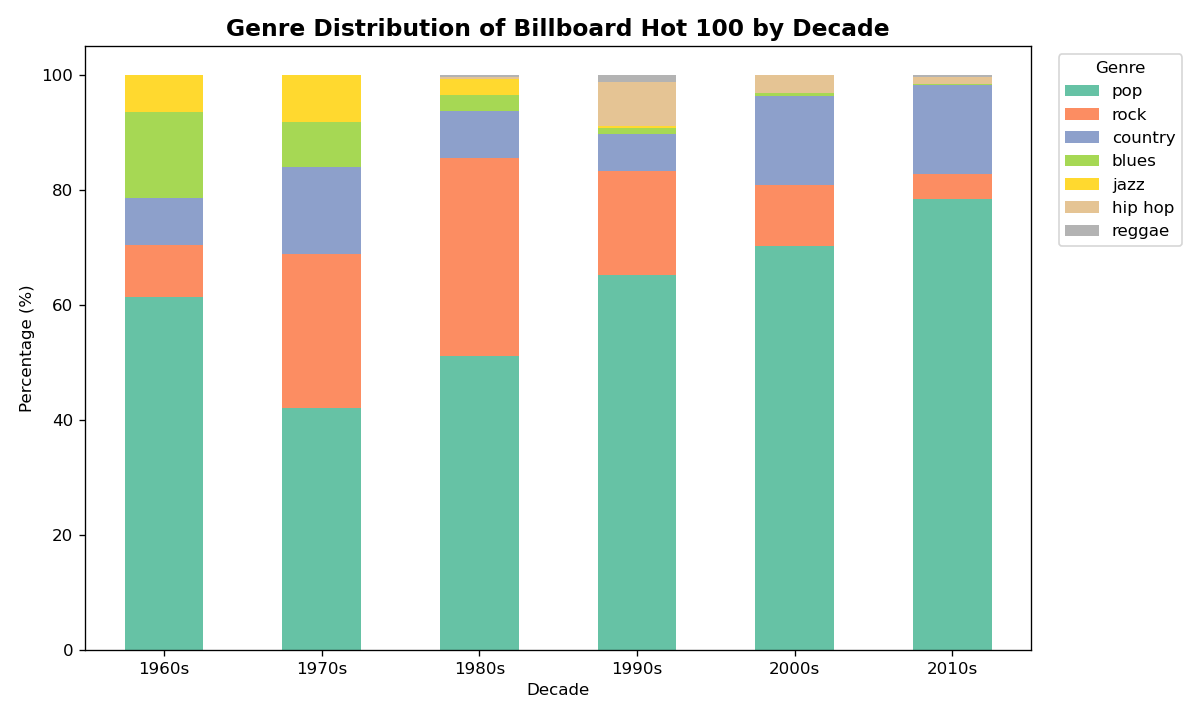
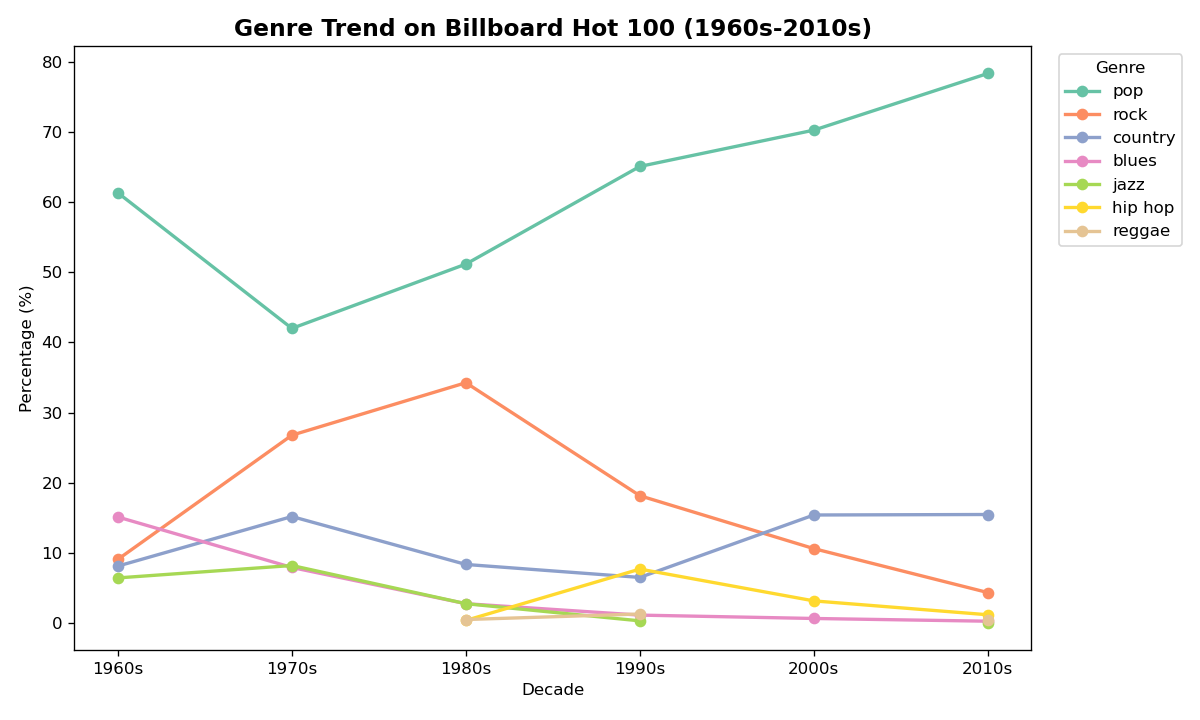

In [2]:
show_row(["rq1_genre_stacked_bar.png", "rq1_genre_line.png"])

## 4. Results — RQ2: Emotional Evolution of Popular Music

Across the five audio features tracked, **Acousticness** declined sharply, while **Energy** and **Danceability** steadily increased. This shift reflects a transition from acoustic instrumentation to synthetic production, alongside the growing dominance of high-energy and dance-oriented rhythms.

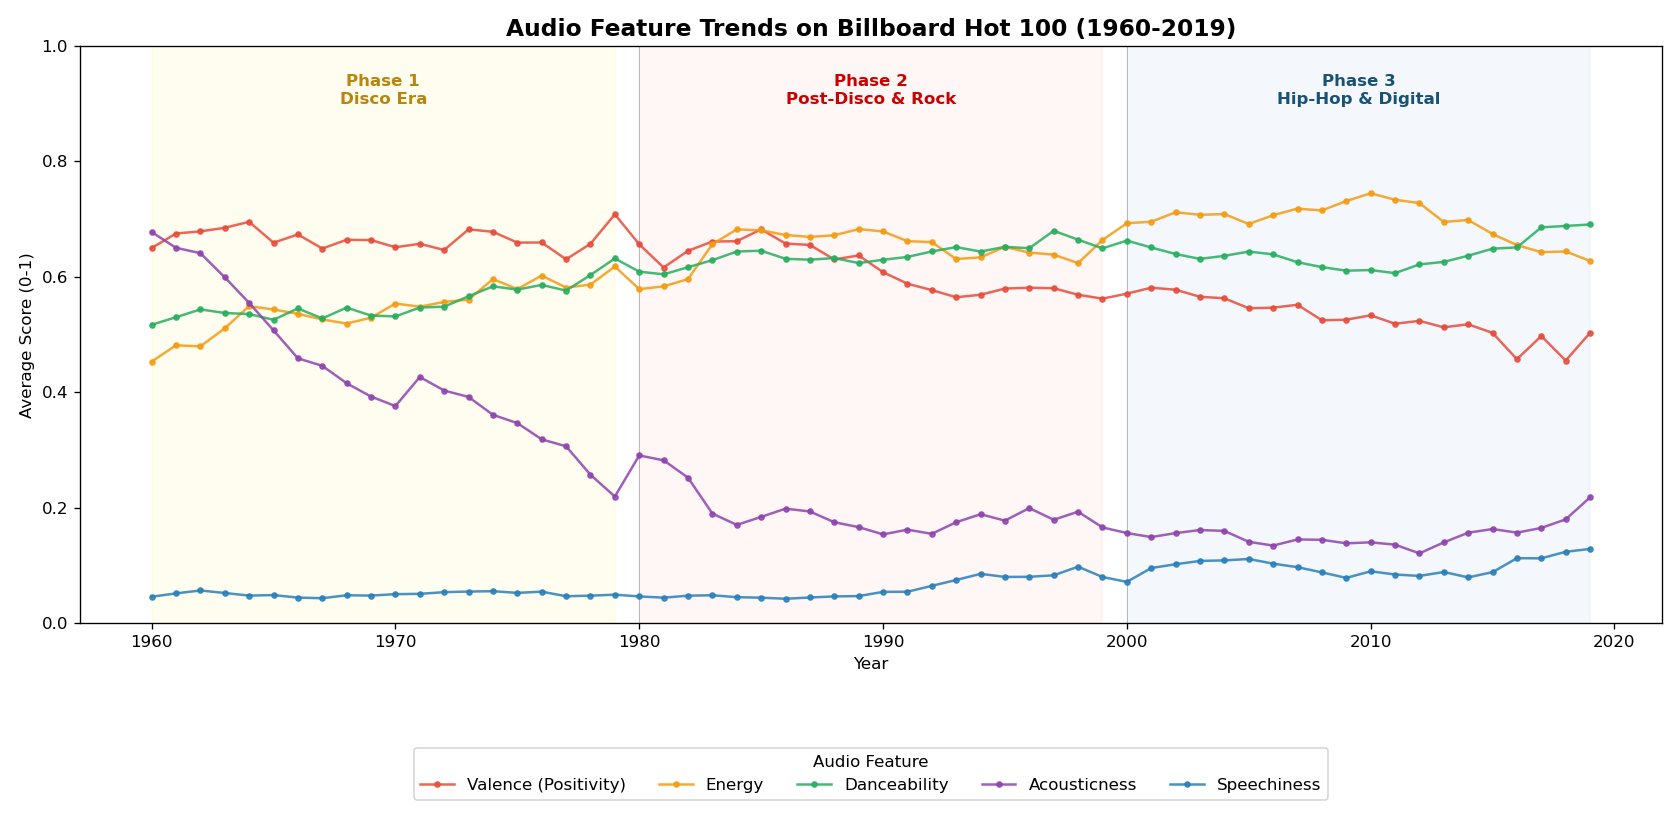

In [3]:
show("rq2_five_features_trend.png")

the most striking pattern is the **divergence between Valence and Energy**: 

- **Valence** fell from **0.650** (1960) to **0.503** (2019), a ~22.6% decline.
- **Energy** rose from **0.453** (1960) to **0.628** (2019) over the same period.
> As a result, **Modern popular music since 1985** is not simply "sadder", presenting a darker emotional tone balanced by a more energetic and forceful presence.

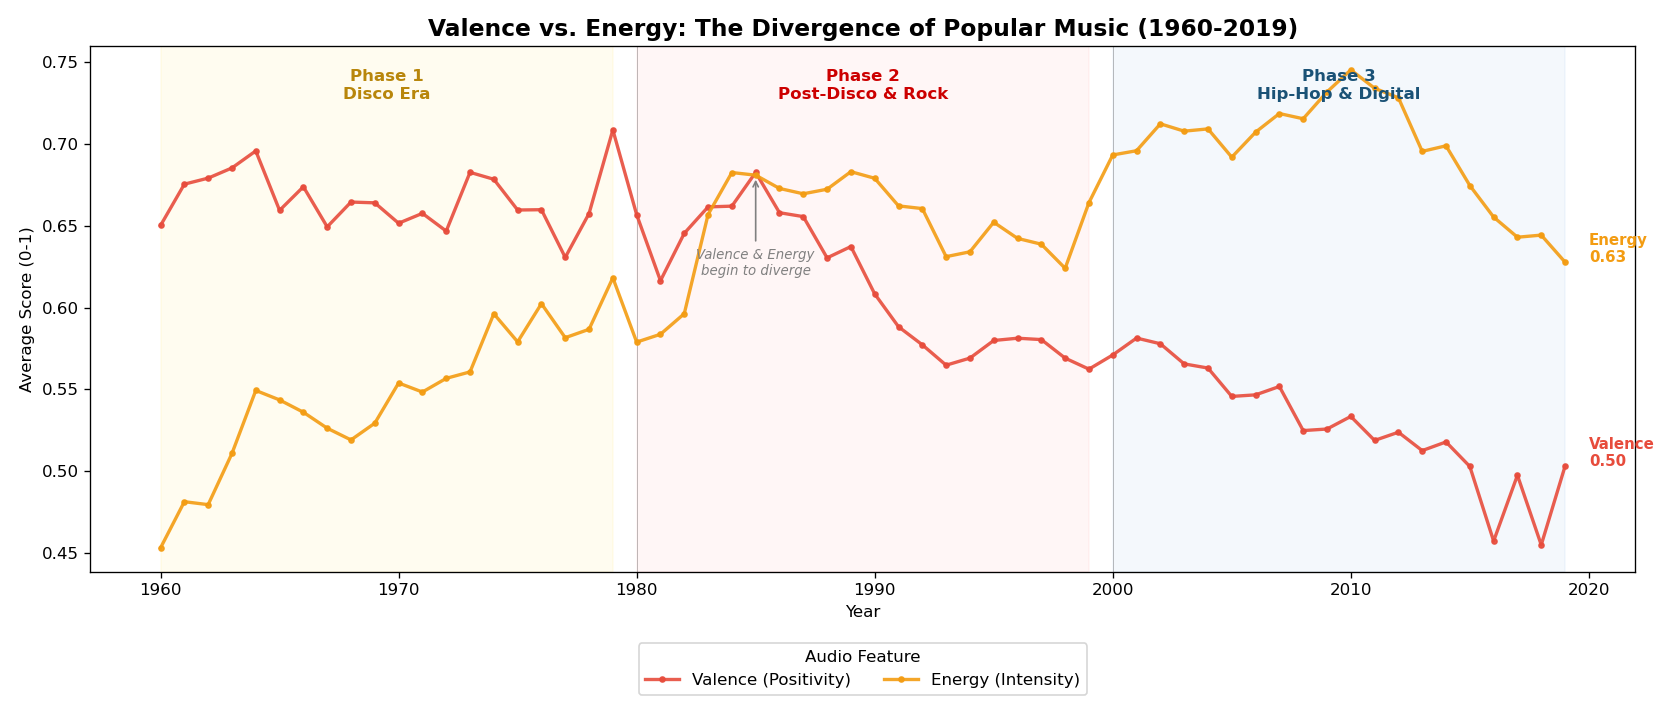

In [4]:
show("rq2_valence_energy_divergence.png")

### Longest-Charting Song per Decade

For each decade, the single song that spent the most weeks on the Billboard Hot 100, alongside its Acousticness, Valence, and Energy

| Decade | Song | Artist | Weeks on Chart | Acousticness | Valence | Energy |
|---|---|---|--:|--:|--:|--:|
| 1960s | The Twist | Chubby Checker | 39 | 0.202 | 0.937 | 0.638 |
| 1970s | I Go Crazy | Paul Davis | 40 | 0.259 | 0.271 | 0.457 |
| 1980s | Tainted Love | Soft Cell | 43 | 0.558 | 0.626 | 0.450 |
| 1990s | How Do I Live | LeAnn Rimes | 69 | 0.128 | 0.258 | 0.462 |
| 2000s | I'm Yours | Jason Mraz | 76 | 0.957 | 0.307 | 0.107 |
| 2010s | Radioactive | Imagine Dragons | 87 | 0.106 | 0.236 | 0.784 |

## 5. Results — RQ3: Speechiness and the Mainstreaming of Hip-Hop

**Speechiness** — Spotify's measure of spoken-word quality — rose from **0.0461 in 1960** to **0.1289 in 2019**, a **179.6%** increase, one of the most dramatic structural shifts in the chart's sonic profile. Genre-level analysis confirms Hip-Hop drives this: its average speechiness (**0.2325**) dwarfs every other genre.

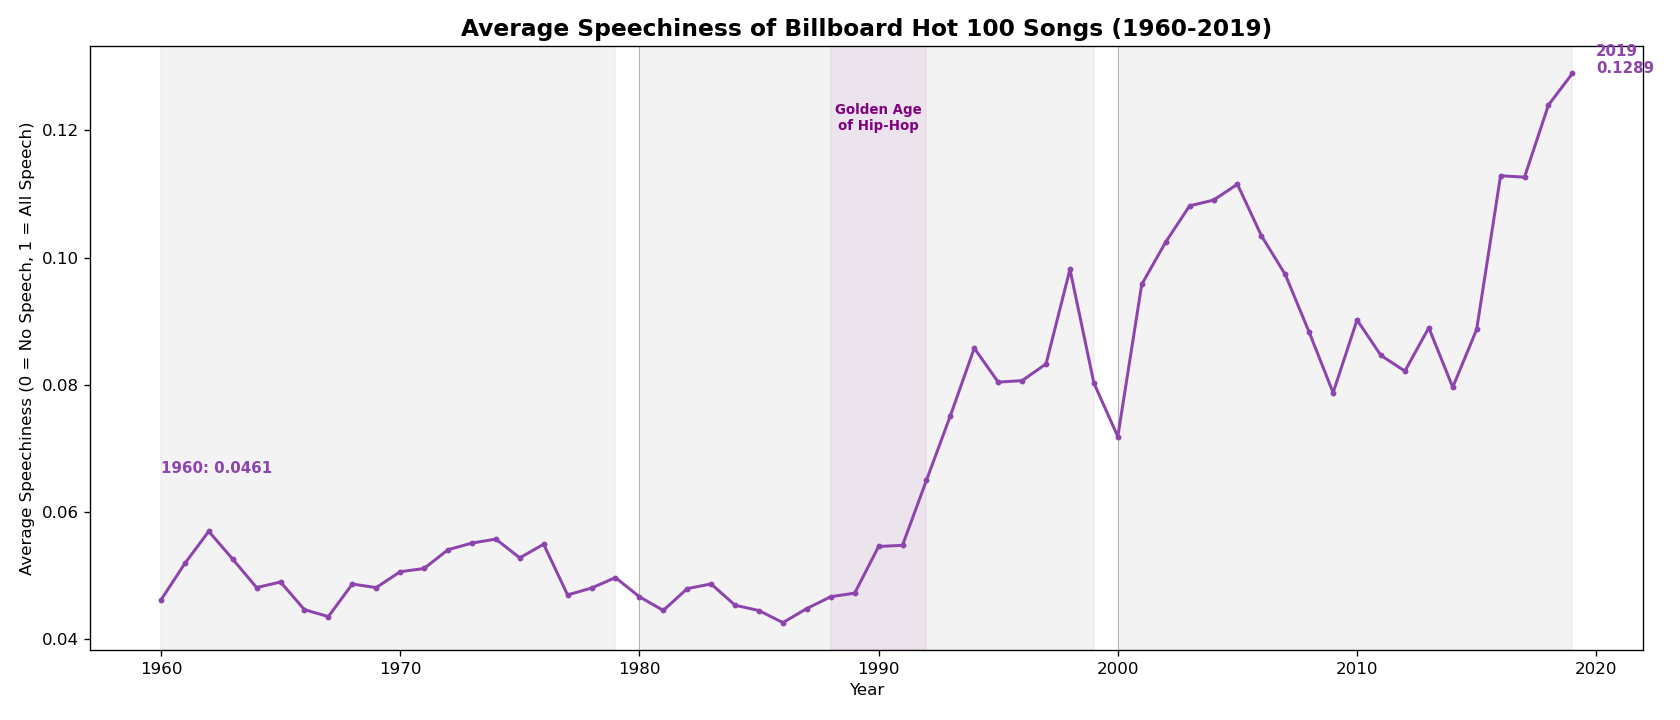

In [5]:
show("rq3_speechiness_trend.png")

### Where the Rise Comes From

Genre-level analysis confirms Hip-Hop drives this: its average speechiness (**0.2325**) sits far above every other genre tracked.

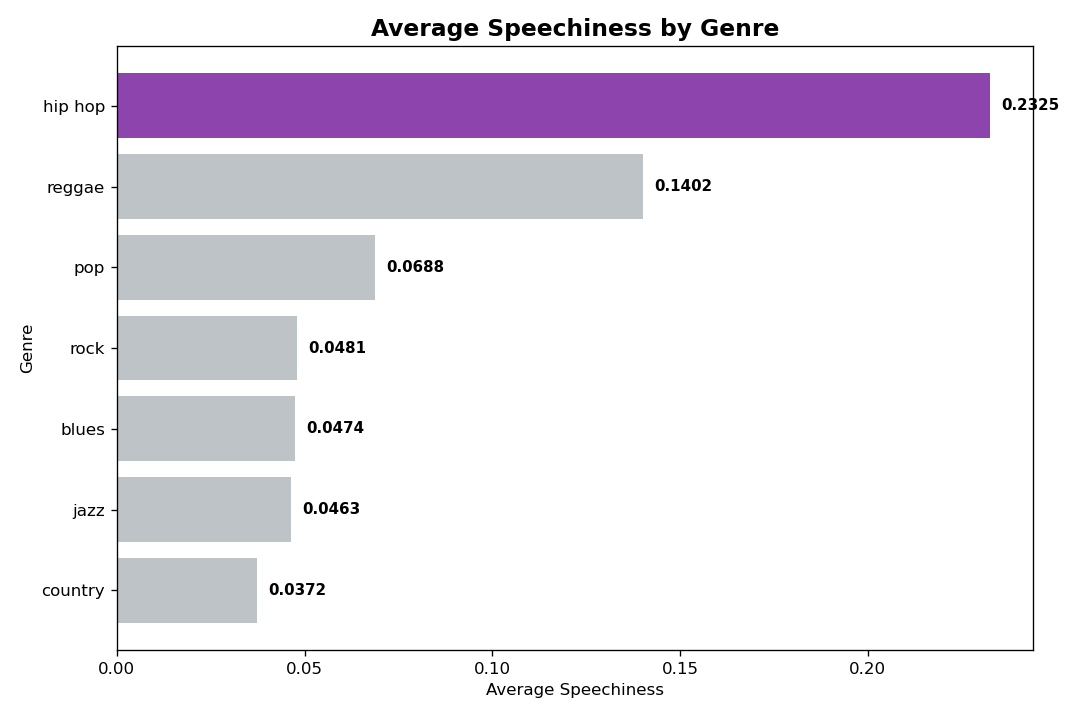

In [6]:
show("rq3_speechiness_genre.png", width=760)

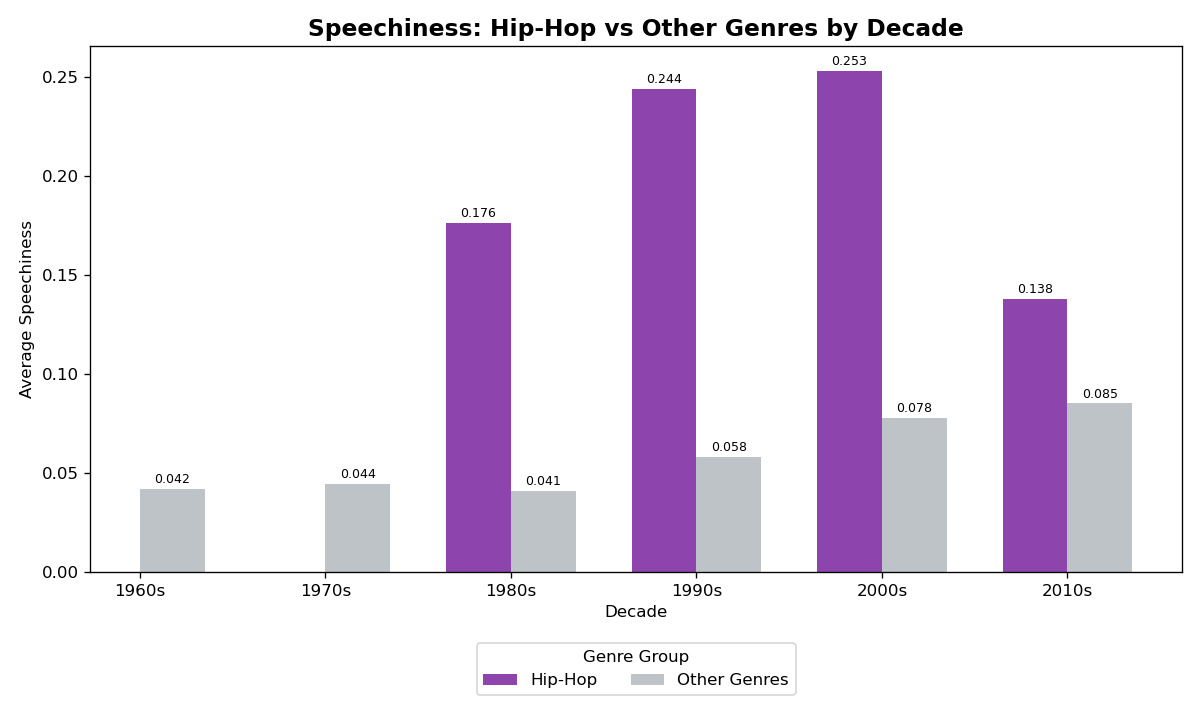

In [7]:
show("rq3_hiphop_vs_other.png", width=760)

A naive average of each genre's own mean would put "Other Genres" at 0.0646 — a 4.8x gap — but with genre sample sizes this unequal (reggae has 159 rows, pop has 27,700), that overstates it. The correct row-weighted average across every song gives Other Genres **0.0603**, and Hip-Hop's real ratio is **3.86x**. Breaking the comparison down by decade (above) shows the gap holds consistently across all six decades, not just one era.

**Caveat:** genre labels only cover 14-19% of the dataset (unevenly across decades) — this genre-level comparison rests on that subset. Speechiness itself is 100% complete, so the overall upward trend across the whole chart isn't affected by this limitation.

## 6. Results — RQ4: Audio Features and Chart Success

To identify which audio features are most strongly associated with chart success, this section uses two classification models on D2 (Spotify Hit Predictor), a dataset independently balanced 50/50 Hit/Flop.

- **Logistic Regression**   (explanatory: coefficients + significance) 
- **Random Forest**   (predictive strength + non-linear relationships) 

D1 (Billboard charts) contains only weekly Hot 100 charted songs. Joining D1 to D2 for this task produces a `target` distribution of 80.06% Hit, 0.06% Flop (264,281 vs. 197 rows), resulting in a dataset with essentially no negative examples to learn from. **RQ4 deliberately uses D2 alone, which was independently constructed to be 50/50 balanced, avoiding this data-leakage trap entirely.**

*(Separately verified: 99.92% of D2's Hit songs do match real Billboard chart history, and only 0.12% of D2's Flop songs do, which confirms D2's labels are trustworthy even though they can't be merged with D1 for modeling.)*

### 6.1 Model Performance

| Model | Accuracy | AUC | Sensitivity (Hit) | Specificity (Flop) |
|---|---|---|---|---|
| Logistic Regression | 0.7293 | 0.8071 | 0.8095 | 0.6490 |
| Random Forest | 0.7842 | 0.8666 | 0.8329 | 0.7356 |

- **The Random Forest model** achieved an AUC of 0.87 (or 0.867), outperforming the standard Logistic Regression model (AUC = 0.80)
- Random Forest outperforms Logistic Regression on every metric, **suggesting the relationship between audio features and chart success involves non-linear interactions**. *LR's linear formula cannot fully capture.*


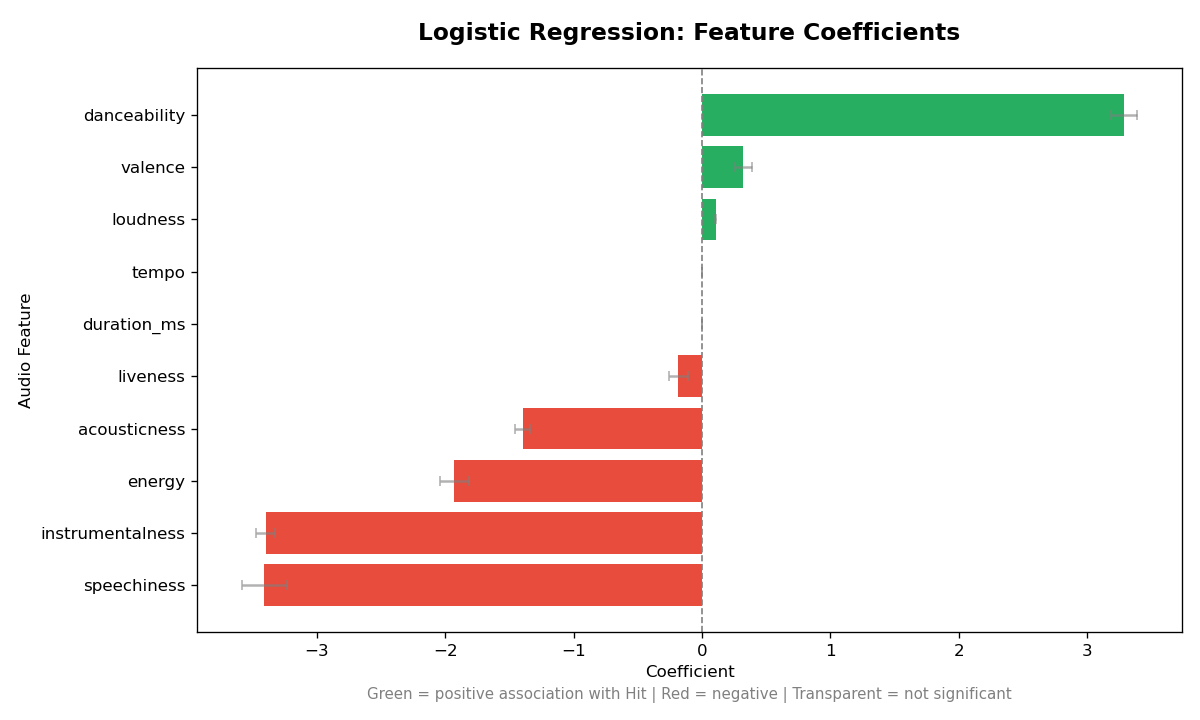
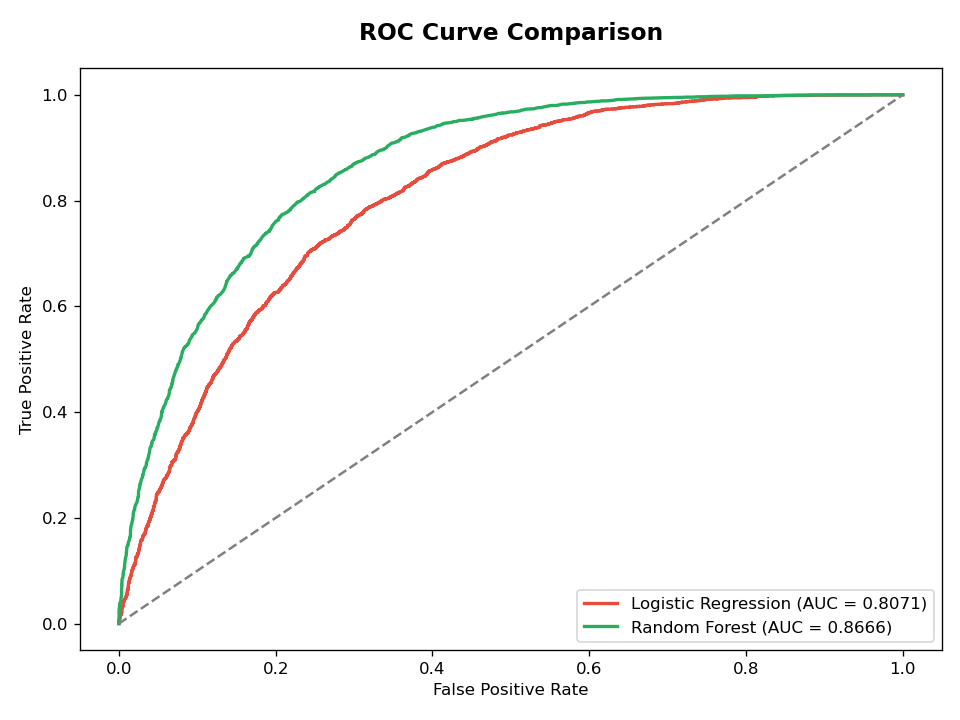

In [8]:
show_row(["rq4_lr_coefficients.png", "rq4_roc_comparison.png"])

### 6.2 Which Features Matter Most


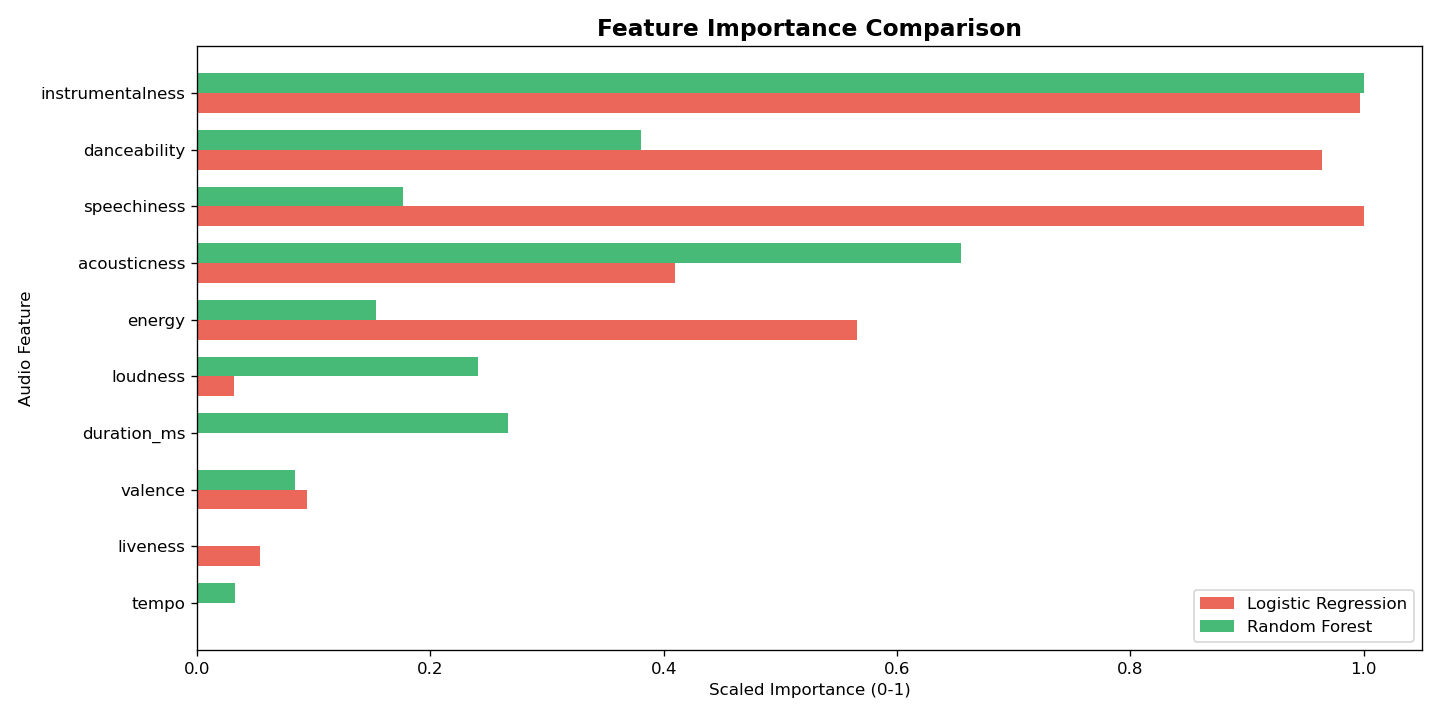

In [9]:
show("rq4_importance_comparison.png")

**Chart Note:** 

- LR importance = coefficient magnitude (linear effect)
- RF importance = permutation importance (accuracy drop when shuffled)

They are not the same scale. Agreement across both signals a robust finding; divergence signals a non-linear or interaction effect. 

> *Strong alignment across both metrics indicates high findings reliability, whereas substantial divergence signals a non-linear/interaction effect, or redundancy with a correlated feature*

Comparing key features reveals both clear model alignment and notable divergence:

**1. Agreement signals**

- **instrumentalness** (negative — vocal-absent tracks rarely chart)
- **acousticness** (negative — electronic production has displaced acoustic instrumentation)
- **danceability** (positive — Strong rhythmic drive significantly favors hit potential)

**2. Substantial divergence signals**

- **energy** and **speechiness**
    - *The reason for energy* — *Feature Redundancy* : A correlation check found energy highly correlated with loudness (r=0.773) and acousticness (r=-0.715). Its modest permutation-importance rank (despite a high Gini-importance rank) reflects redundancy, not unimportance.
    - *The reason for speechiness* — *Decade Interaction* : A decade-split check found speechiness's effect on Hit-likelihood flips — negative pre-1990, positive from the 1990s on (not redundancy: |r| ≤ 0.156). LR's single coefficient averages this reversal into insignificance; RF, without ever seeing decade directly, still partially captures it through combinations of the other features.

### 6.3 Extension: Can the Model Explain More?

The 10-feature LR model's Pseudo R² of **0.232** means these audio features explain roughly 23% of what separates a Hit from a Flop — expected for an *Explanatory*, not *Predictive*, model (see Section 7). **Two extensions** were tested to see whether this could be pushed further without new data collection:

1. **Technology era** (`pre_digital` / `digital_download` / `streaming`, derived from D2's `decade` field) — controls for the known "60 years pooled together" limitation.
2. **Interaction terms** (`danceability×energy`, `instrumentalness×acousticness`, `danceability×valence`) — Section 6.1 RF's AUC advantage over LR (0.87 vs 0.80) suggested LR was missing combination effects; these three pairs were chosen because each term individually already ranks among the most important features, they have a plausible musical rationale, and none pairs two variables already flagged as redundant in the correlation check.

    - **Instrumentalness × Acousticness:** To test whether "organic, largely-instrumental" tracks behave as one coherent musical identity.
    - **Danceability × Energy:** To test whether danceability only translates into hit potential once it's paired with enough physical intensity.
    - **Danceability × Valence:** To test whether pairing maximum danceability with maximum positivity produces a song with less distinctive character than pairing danceability with a more complex, less uniformly cheerful tone.

| Metric | Original (10 features) | Extended (+ era + interactions, 15 features) | Change |
|---|---|---|---|
| Pseudo R² | 0.2320 | 0.2544 | **+0.0224** |
| Accuracy | 0.7293 | 0.7426 | +0.0133 |
| AUC | 0.8071 | 0.8171 | +0.0100 |
| Specificity | 0.6490 | 0.6779 | **+0.0289** |


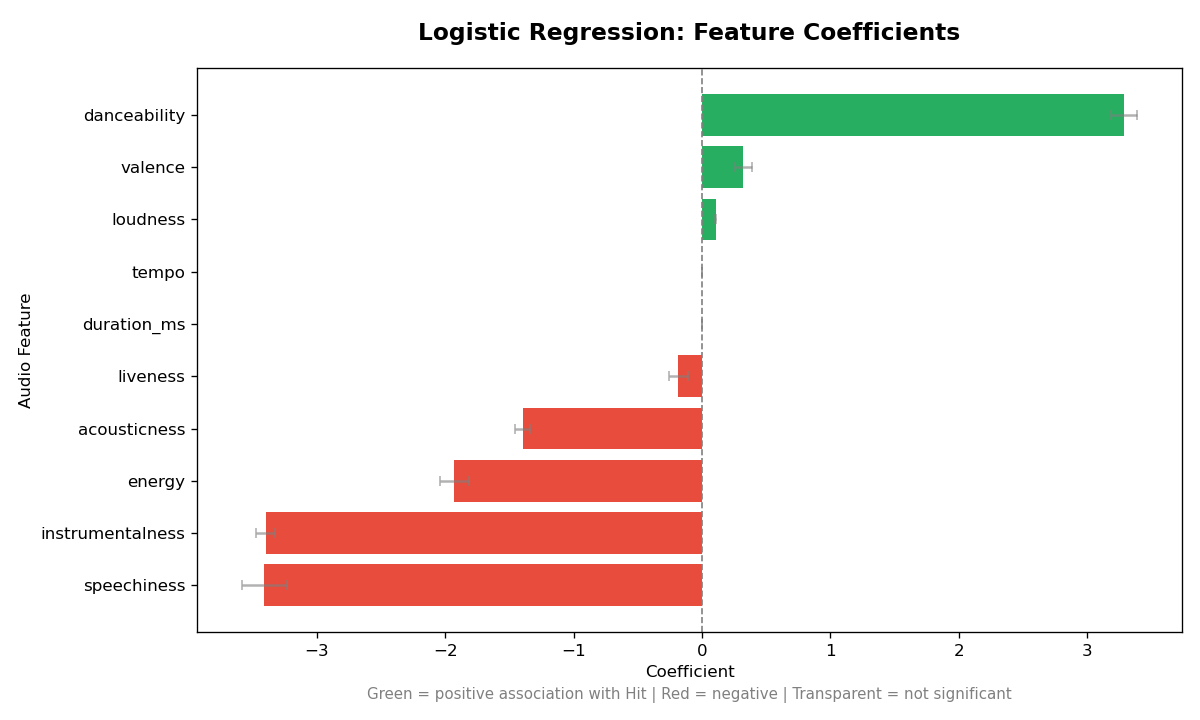
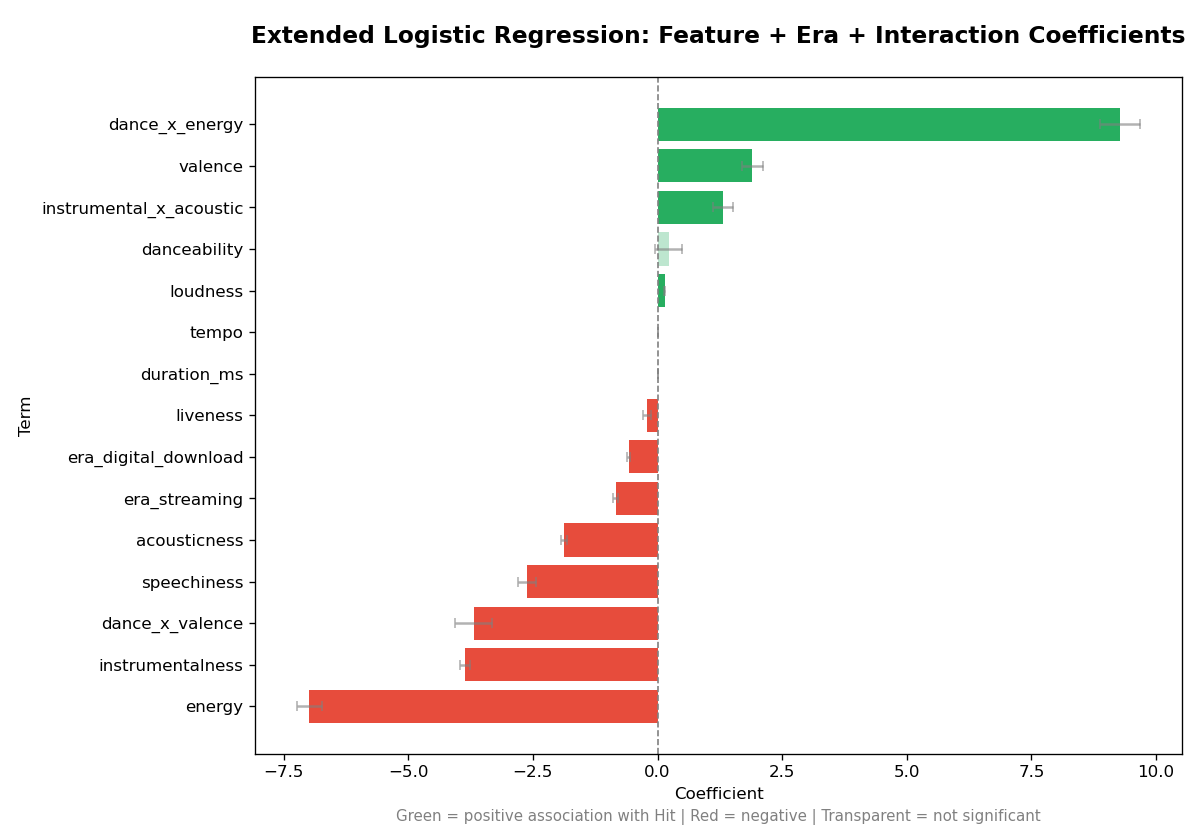

In [10]:
show_row(["rq4_lr_coefficients.png", "rq4_extended_coefficients.png"])

**Key Insight:** 

- **danceability × energy is the single strongest driver** in the extended model (+9.28) — outperforming every individual feature.
- **Standalone effect shift:**  Once interaction terms are introduced, `danceability`'s individual coefficient loses statistical significance (p=0.403). This reveals that danceability impacts hit potential almost entirely through its combined interaction with `energy` and `valence`, rather than as an isolated trait.

## 7. Limitations

### 7.1 Data Coverage

| Limitation | Description |
|---|---|
| D3 genre coverage | Only 14-19% of `analysis_base` has a matched genre label, and coverage is uneven by decade — genre-specific findings (RQ1, RQ3's genre breakdown) are directional, not exact |
| D2 join rate | ~80% of D1 records have matched Spotify audio features; ~20% of chart entries are missing this data, a possible source of selection bias |
| Time range | 1960-2019 only, to keep consistent coverage across all three datasets |
| D2 date granularity | D2 has decade-level labels only, not exact release year — the Section 6.3 "technology era" feature is a decade-level approximation, not a precise pre/post-launch-date split |

### 7.2 D3's Genre Field Is an Untraceable Black Box

D3's `genre` label traces back to a genre-filtered Spotify search (one query per genre, via the `spotipy` library) — not an independent, song-level classification. Two separate access points into how this actually works were checked, and both dead-end:

- **The source paper's own citation is now broken.** Its one Spotify-API reference — "for Developers., S. Get audio features for a track. Available at https://developer.spotify.com/documentation/web-api/reference/tracks/get-audio-features/" — returns **HTTP 404** as of this writing. The paper itself only states that data was fetched "using spotipy... to search for specific genres, artists, songs, release dates, etc.", with no further methodology.
- **Spotify's own current documentation doesn't fill the gap either.** It confirms a `genre` search filter can be applied to track searches, but never discloses the matching logic behind it — i.e. how a track by an artist tagged with several genres gets assigned to any one of them.

**This is a limitation of the data source itself, not an oversight of this analysis** — the mechanism cannot be traced further with what either the paper or Spotify has published.

### 7.3 Modeling Assumptions

**Temporal pooling:** six decades of data are pooled into one model — feature-hit relationships plausibly shift by era, and Section 6.2's speechiness finding (its effect on hit-likelihood flips sign before/after 1990) is direct evidence of exactly that. The pooled coefficients are therefore an average across eras that may each run on a somewhat different "hit formula." A full decade-by-decade model, which would test how far this goes, is listed as future work in Section 8.

**Explanatory, not predictive:** RQ4's goal is to understand historical associations, not to forecast future hits. A Pseudo R² around 0.23-0.25 means most of what separates a Hit from a Flop is not captured by audio features alone — that is an expected, not a failing, result for this kind of analysis (see 7.5).

**Label definition:** D2's Hit/Flop labels come from the dataset author's own criteria, not directly from official Billboard placement — though a direct check found 99.92% of D2's labeled Hits do match real Billboard chart history.

### 7.4 What External Data Could Not Fix

A search for additional Kaggle datasets covering marketing spend, artist popularity, or social reach (to explain the ~75% of hit-status this model cannot account for) found several genuinely useful *current* datasets — but none with historical coverage matching 1960-2019. Streaming-era metrics like YouTube views or Spotify's live `popularity` score reflect a song's standing *today*, not its marketing push or cultural reach at the time it originally charted, especially pre-1999 when no such platforms existed. **This is a real data-availability limitation, not an unexplored research direction** — no free or low-cost dataset currently bridges six decades of historical marketing data.

### 7.5 Spotify Audio Features

Valence, Energy, Speechiness, and the other audio features are estimated purely from the audio signal (rhythm, timbre, harmonic content) — they capture the *sonic* dimension of a track, not lyrical meaning or cultural context. A song can score high on Valence (musically "positive-sounding") while its lyrics convey something entirely different — this is a known limitation of the features themselves, not an error in this analysis.

## 8. Conclusion

| RQ | Question | Key Finding |
|---|---|---|
| RQ1 | Genre distribution across decades? | Pop rose 61.4%→78.4%; Rock peaked 34.3% (1980s) then collapsed to 4.3%; Blues fell from 15.1% to near zero |
| RQ2 | How has emotional tone evolved? | Valence fell ~22.6% while Energy rose — modern hits are darker but more forceful, not simply "sadder"; the social-unrest causal story does not hold up against the actual timeline |
| RQ3 | Does speechiness reflect Hip-Hop's rise? | Speechiness rose 103.1% overall (1960s→2010s); Hip-Hop drives this most intensely (3.86x the row-weighted average of every other genre), and the gap holds consistently across all six decades |
| RQ4 | Which audio features predict chart success? | Instrumentalness, danceability, and acousticness are the strongest hit signals across 60 years, with RF (AUC 0.867) outperforming LR (AUC 0.807) — evidence of non-linear effects LR's linear formula can't fully capture. Adding technology-era controls and 3 interaction terms lifts Pseudo R² from 0.232 to 0.254; danceability × energy (+9.28) is the single strongest driver in the extended model, and danceability's own standalone effect only becomes significant once that interaction is accounted for |

### Broader Implications

Across all four questions, popular music's evolution reads as coherent rather than random: the rhythmic, speech-heavy aesthetic that RQ3 traces to Hip-Hop's mainstreaming helps explain part of RQ2's valence decline; the structural features that dominate RQ4's models (danceability, low instrumentalness) reflect the same genre shift RQ1 documents at the chart level. None of these four findings stand alone — they are four views of the same six-decade transition.

### Future Research Directions

- **Full decade-by-decade modeling** — Section 6.2's speechiness finding (its effect on hit-likelihood flips sign before/after 1990) hints that feature-hit relationships shift by era; running a separate model per decade would test how far that goes, and whether every era has an equally strong "hit formula"
- **The five unused D2 columns** (`key`, `mode`, `time_signature`, `chorus_hit`, `sections`) — available at zero additional data-collection cost, not yet tested against Pseudo R²
- **Artist-frequency proxy for fame** — derivable from D2's own `artist` field, with an explicit circularity caveat, as a low-cost alternative to the external popularity data this report could not obtain (Section 7.3)
- **International markets** — this analysis is U.S.-only; whether these trends generalize elsewhere is untested
- **Live Spotify Artist API instead of the static D3 snapshot** — would be a more current, directly-citable genre source than a 2022 Kaggle file, and the basic Get Artist endpoint (unlike Audio Features/Recommendations/Related Artists) is not on Spotify's Nov 2024 restricted-endpoint list, so it remains accessible. Two limits carry over regardless of data freshness, though: genre attaches to the *artist* object, not the *track*, and is frequently multi-valued with no indicator of which tag applies to any specific song (Spotify's own documented example: `"genres": ["Prog rock", "Grunge"]`) — an artist active across eras or styles offers no way to resolve which label fits *this* song, so this ambiguity would persist even with 100% coverage